# Give Me Some Credit - Estudo


## 1. Leitura dos dados


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

treino_0 = pd.read_csv('GiveMeSomeCredit/cs-training.csv')
teste_0 = pd.read_csv('GiveMeSomeCredit/cs-test.csv')

cols = {
    'Unnamed: 0': 'id',
    'SeriousDlqin2yrs': 'default_2y',
    'RevolvingUtilizationOfUnsecuredLines': 'credit_utilization',
    'age': 'age',
    'NumberOfTime30-59DaysPastDueNotWorse': 'late_30_59_days',
    'DebtRatio': 'debt_ratio',
    'MonthlyIncome': 'monthly_income',
    'NumberOfOpenCreditLinesAndLoans': 'num_credit_lines',
    'NumberOfTimes90DaysLate': 'late_90_days',
    'NumberRealEstateLoansOrLines': 'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'late_60_89_days',
    'NumberOfDependents': 'dependents'
}

treino = treino_0.rename(columns=cols).copy()
teste = teste_0.rename(columns=cols).copy()

treino.drop(columns = 'id', inplace = True)
teste.drop(columns = 'id', inplace = True)

treino.head()

,default_2y,credit_utilization,age,late_30_59_days,debt_ratio,monthly_income,num_credit_lines,late_90_days,real_estate_loans,late_60_89_days,dependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Conhecendo os dados

Verificar tamanho dos dados, desbalanceamento da target e faltantes.

In [2]:
treino.describe()

,default_2y,credit_utilization,age,late_30_59_days,debt_ratio,monthly_income,num_credit_lines,late_90_days,real_estate_loans,late_60_89_days,dependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [3]:
teste.describe()

,default_2y,credit_utilization,age,late_30_59_days,debt_ratio,monthly_income,num_credit_lines,late_90_days,real_estate_loans,late_60_89_days,dependents
count,0.0,101503.000000,101503.000000,101503.000000,101503.000000,8.140000e+04,101503.000000,101503.000000,101503.000000,101503.000000,98877.000000
mean,NaN,5.310000,52.405436,0.453770,344.475020,6.855036e+03,8.453514,0.296691,1.013074,0.270317,0.769046
std,NaN,196.156039,14.779756,4.538487,1632.595231,3.650860e+04,5.144100,4.515859,1.110253,4.503578,1.136778
min,NaN,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,0.030131,41.000000,0.000000,0.173423,3.408000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,0.152586,52.000000,0.000000,0.364260,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,NaN,0.564225,63.000000,0.000000,0.851619,8.200000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,NaN,21821.000000,104.000000,98.000000,268326.000000,7.727000e+06,85.000000,98.000000,37.000000,98.000000,43.000000


Podemos observar dados faltantes em ambos conjuntos de dados. Alem disso, temos linhas com 'age' igual a zero.

In [4]:
def resumo_faltantes(df):
    tabela = pd.DataFrame({
        'faltantes': df.isna().sum(),
        'faltantes (%)': df.isna().mean().mul(100)
    })
    return tabela[tabela['faltantes'] > 0].sort_values('faltantes', ascending=False)

print('Shape treino:', treino.shape)
print('Shape teste:', teste.shape)
print('\nTaxa de default nos dados de treino: {:.2%}'.format(treino['default_2y'].mean()))

display(resumo_faltantes(treino))
display(resumo_faltantes(teste))

Shape treino: (150000, 11)
Shape teste: (101503, 11)

Taxa de default nos dados de treino: 6.68%


,faltantes,faltantes (%)
monthly_income,29731,19.820667
dependents,3924,2.616000


,faltantes,faltantes (%)
default_2y,101503,100.000000
monthly_income,20103,19.805326
dependents,2626,2.587116


Text(0.5, 1.0, 'Matriz de correlações de Pearson')

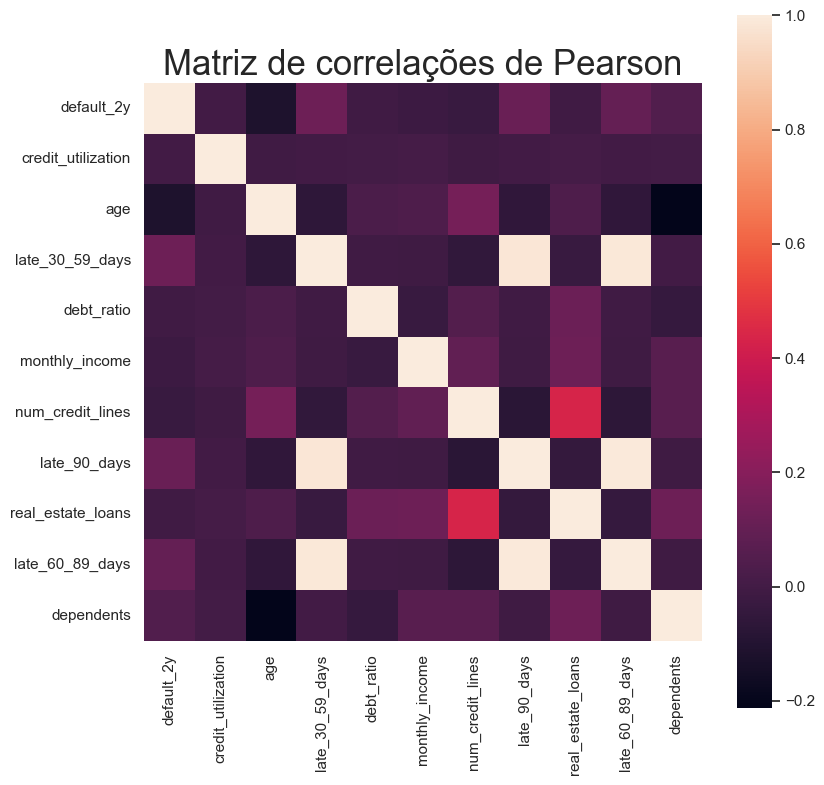

In [23]:
fig1, ax = plt.subplots(figsize=(9,9))
sns.heatmap(treino.corr(), square=True)

plt.title('Matriz de correlações de Pearson',fontsize=25)

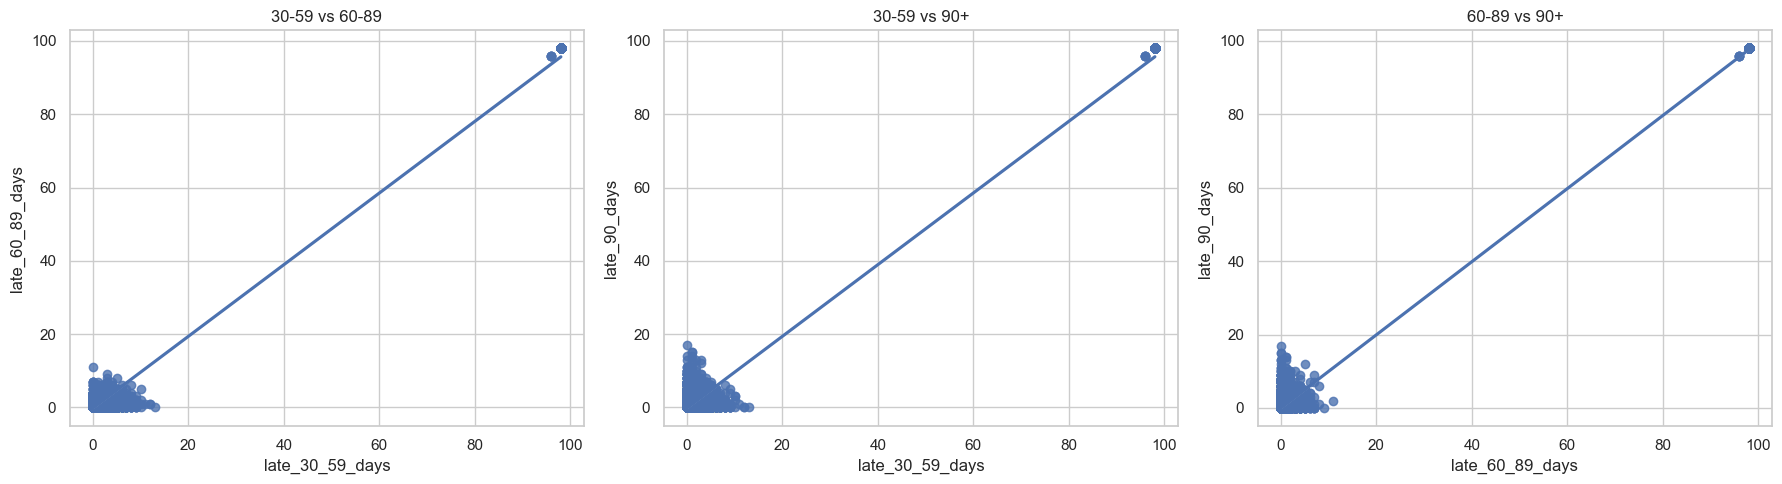

In [25]:
fig2, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 30-59 vs 60-89
sns.regplot(
    x='late_30_59_days',
    y='late_60_89_days',
    data=treino,
    ax=axes[0]
)
axes[0].set_title('30-59 vs 60-89')

# 2) 30-59 vs 90+
sns.regplot(
    x='late_30_59_days',
    y='late_90_days',
    data=treino,
    ax=axes[1]
)
axes[1].set_title('30-59 vs 90+')

# 3) 60-89 vs 90+
sns.regplot(
    x='late_60_89_days',
    y='late_90_days',
    data=treino,
    ax=axes[2]
)
axes[2].set_title('60-89 vs 90+')

plt.tight_layout()
plt.show()

In [30]:
cols_late = ['late_30_59_days', 'late_60_89_days', 'late_90_days']

df_late_sem_extremos = treino.loc[
    (train_clean[cols_late] <= 80).all(axis=1),
    cols_late
]

df_late_sem_extremos.corr()

corr_late_sem_extremos = df_late_sem_extremos.corr()
print(corr_late_sem_extremos)

                 late_30_59_days  late_60_89_days  late_90_days
late_30_59_days         1.000000         0.305876      0.218147
late_60_89_days         0.305876         1.000000      0.294638
late_90_days            0.218147         0.294638      1.000000


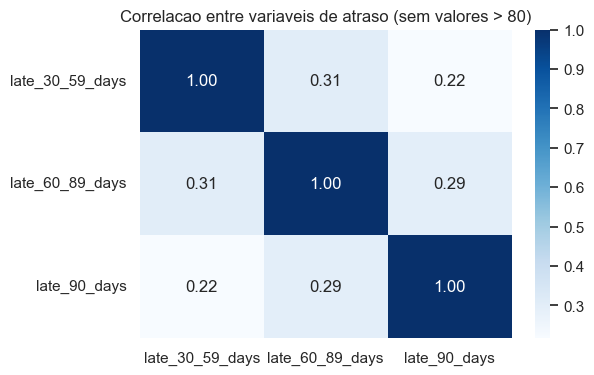

In [31]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr_late_sem_extremos, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlacao entre variaveis de atraso (sem valores > 80)')
plt.show()

Como podemos observar pelos gráficos acima, podemos nos enganar e acreditar que as variaveis late tem uma dependencia linear, mas isso ocorre por conta de alguns dados com valores grandes que puxam essa correlacao para próximo de 1.

No entanto, podemos fazer uma transformação para agrupar as informações dessa variável em uma outra variável, simplificando o modelo.

Na próxima seção, vamos tratar os dados faltantes e adicionar a variável `late_score` agrega as variáveis `late_30_59_days`, `late_60_89_days` e `late_90_days` fazendo uma soma ponderada, atribuindo a maior importancia ao maior atraso.

## 3. Tratamento dos dados

As decisoes desta etapa foram:

- substituir `age == 0` pela mediana das idades validas;
- criar flags de faltantes para `monthly_income` e `dependents`;
- imputar `monthly_income` e `dependents` usando a mediana por faixa etaria calculada **no treino**;
- reaproveitar as medianas do treino ao tratar o conjunto de teste.

In [5]:
def tratar_dados(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    idade_mediana = train_df.loc[train_df['age'] > 0, 'age'].median()
    train_df.loc[train_df['age'] < 18, 'age'] = idade_mediana
    test_df.loc[test_df['age'] < 18, 'age'] = idade_mediana

    for col in ['monthly_income', 'dependents']:
        train_df[f'{col}_missing'] = train_df[col].isna().astype(int)
        test_df[f'{col}_missing'] = test_df[col].isna().astype(int)

    bins = [18, 30, 60, 120]
    labels = ['jovem', 'adulto', 'idoso']
    train_df['age_band'] = pd.cut(train_df['age'], bins=bins, labels=labels, include_lowest=True)
    test_df['age_band'] = pd.cut(test_df['age'], bins=bins, labels=labels, include_lowest=True)

    income_medians = train_df.groupby('age_band', observed=False)['monthly_income'].median()
    dep_medians = train_df.groupby('age_band', observed=False)['dependents'].median()

    train_df['monthly_income'] = train_df['monthly_income'].fillna(train_df['age_band'].map(income_medians))
    test_df['monthly_income'] = test_df['monthly_income'].fillna(test_df['age_band'].map(income_medians))

    train_df['dependents'] = train_df['dependents'].fillna(train_df['age_band'].map(dep_medians))
    test_df['dependents'] = test_df['dependents'].fillna(test_df['age_band'].map(dep_medians))

    train_df['late_score'] = (
        1 * train_df['late_30_59_days'] +
        2 * train_df['late_60_89_days'] +
        3 * train_df['late_90_days']
    )
    test_df['late_score'] = (
        1 * test_df['late_30_59_days'] +
        2 * test_df['late_60_89_days'] +
        3 * test_df['late_90_days']
    )

    return train_df, test_df, income_medians, dep_medians

train_clean, test_clean, income_medians, dep_medians = tratar_dados(treino, teste)

print('Medianas de renda por faixa etaria:')
display(income_medians)
print('Medianas de dependentes por faixa etaria:')
display(dep_medians)

display(resumo_faltantes(train_clean))
display(train_clean[['age', 'monthly_income', 'dependents', 'late_score']].describe())

Medianas de renda por faixa etaria:


age_band
jovem     2779.5
adulto    5833.0
idoso     5223.0
Name: monthly_income, dtype: float64

Medianas de dependentes por faixa etaria:


age_band
jovem     0.0
adulto    1.0
idoso     0.0
Name: dependents, dtype: float64

,faltantes,faltantes (%)


,age,monthly_income,dependents,late_score
count,150000.000000,1.500000e+05,150000.000000,150000.000000
mean,52.295553,6.419363e+03,0.747047,1.699727
std,14.771249,1.289421e+04,1.104911,24.928492
min,21.000000,0.000000e+00,0.000000,0.000000
25%,41.000000,3.778000e+03,0.000000,0.000000
50%,52.000000,5.436000e+03,0.000000,0.000000
75%,63.000000,7.400000e+03,1.000000,0.000000
max,109.000000,3.008750e+06,20.000000,588.000000


## 4. EDA

- Os dados sao desbalanceados ;
- A variavel (`late_score`) parece separar bem os perfis;
- `credit_utilization` tambem tem relacao com o target.

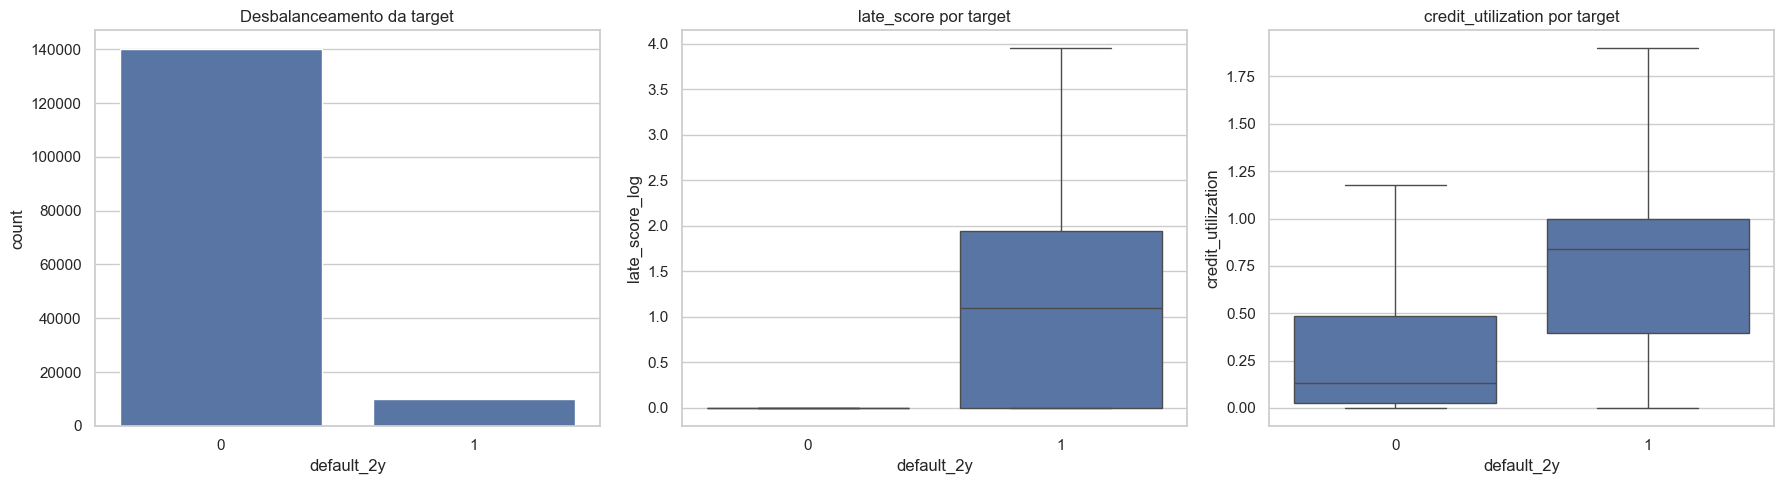

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=train_clean, x='default_2y', ax=axes[0])
axes[0].set_title('Desbalanceamento da target')

sns.boxplot(data=train_clean.assign(late_score_log=np.log1p(train_clean['late_score'])), x='default_2y', y='late_score_log', ax=axes[1], showfliers=False)
axes[1].set_title('late_score por target')

sns.boxplot(data=train_clean, x='default_2y', y='credit_utilization', ax=axes[2], showfliers=False)
axes[2].set_title('credit_utilization por target')

plt.tight_layout()
plt.show()

## 5. Conjunto final de variaveis

Baseado na analise anterior, vou utilizar as variaveis abaixo:

- `late_score`
- `credit_utilization`

In [16]:
features = [
    #'age',
    #'debt_ratio',
    #'monthly_income',
    #'real_estate_loans',
    #'dependents',
    'late_score',
    'credit_utilization'
    #'monthly_income_missing',
    #'dependents_missing'
]

target = 'default_2y'

X = train_clean[features].copy()
y = train_clean[target].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_valid.shape

((120000, 2), (30000, 2))

## 6. Modelo 1 - GLM Logit do statsmodels


In [8]:
X_train_glm = sm.add_constant(X_train, has_constant='add')
X_valid_glm = sm.add_constant(X_valid, has_constant='add')

glm_logit = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial()).fit()

pred_glm_train = glm_logit.predict(X_train_glm)
pred_glm_valid = glm_logit.predict(X_valid_glm)

bin_glm_train = (pred_glm_train >= 0.5).astype(int)
bin_glm_valid = (pred_glm_valid >= 0.5).astype(int)

print(glm_logit.summary())
print('\nGLM Logit - treino')
print('Acuracia:', round(accuracy_score(y_train, bin_glm_train), 3))
print('AUC:', round(roc_auc_score(y_train, pred_glm_train), 3))
print('\nGLM Logit - validacao')
print('Acuracia:', round(accuracy_score(y_valid, bin_glm_valid), 3))
print('AUC:', round(roc_auc_score(y_valid, pred_glm_valid), 3))

                 Generalized Linear Model Regression Results                  
Dep. Variable:             default_2y   No. Observations:               120000
Model:                            GLM   Df Residuals:                   119997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -29135.
Date:                Tue, 28 Apr 2026   Deviance:                       58270.
Time:                        08:01:57   Pearson chi2:                 1.19e+05
No. Iterations:                     6   Pseudo R-squ. (CS):           0.005189
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -2.6598      0

Pelo resultado do p-valor da variável `credit_utilization`, não temos evidencia para rejeitar a hipótese de que o coeficiente dela é zero. Vamos rodar o modelo sem ela.

In [18]:
late_score = ['late_score']

target = 'default_2y'

X2 = train_clean[late_score].copy()
y2 = train_clean[target].copy()

X_train2, X_valid2, y_train2, y_valid2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

X_train2.shape, X_valid2.shape

((120000, 1), (30000, 1))

In [19]:
X_train_glm2 = sm.add_constant(X_train2, has_constant='add')
X_valid_glm2 = sm.add_constant(X_valid2, has_constant='add')

glm_logit = sm.GLM(y_train2, X_train_glm2, family=sm.families.Binomial()).fit()

pred_glm_train2 = glm_logit.predict(X_train_glm2)
pred_glm_valid2 = glm_logit.predict(X_valid_glm2)

bin_glm_train2 = (pred_glm_train2 >= 0.5).astype(int)
bin_glm_valid2 = (pred_glm_valid2 >= 0.5).astype(int)

print(glm_logit.summary())
print('\nGLM Logit - treino')
print('Acuracia:', round(accuracy_score(y_train2, bin_glm_train2), 3))
print('AUC:', round(roc_auc_score(y_train2, pred_glm_train2), 3))
print('\nGLM Logit - validacao')
print('Acuracia:', round(accuracy_score(y_valid2, bin_glm_valid2), 3))
print('AUC:', round(roc_auc_score(y_valid2, pred_glm_valid2), 3))

                 Generalized Linear Model Regression Results                  
Dep. Variable:             default_2y   No. Observations:               120000
Model:                            GLM   Df Residuals:                   119998
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -29135.
Date:                Tue, 28 Apr 2026   Deviance:                       58270.
Time:                        08:19:49   Pearson chi2:                 1.19e+05
No. Iterations:                     6   Pseudo R-squ. (CS):           0.005189
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.6599      0.012   -227.695      0.0

Podemos observar que o AUC ficou maior, indicando que modelo melhorou a performance preditiva só com a variável `credit_utilization`.

## 7. Comparacao de estrategias de selecao de variaveis

Nesta secao comparo tres abordagens para definir o conjunto de variaveis:

- selecao manual, guiada por interpretacao e EDA;
- selecao stepwise com AIC;
- selecao automatica via regressao logistica com regularizacao L1.



In [20]:
def stepwise_aic(X, y, verbose=False):
    X = X.copy()
    X = sm.add_constant(X, has_constant='add')
    included = []
    best_aic = float('inf')

    while True:
        changed = False
        excluded = list(set(X.columns) - set(included) - {'const'})
        candidates = []

        for new_col in excluded:
            try:
                model = sm.GLM(y, X[['const'] + included + [new_col]], family=sm.families.Binomial()).fit()
                candidates.append((model.aic, new_col, 'add'))
            except Exception:
                continue

        for remove_col in included:
            try:
                vars_test = [var for var in included if var != remove_col]
                model = sm.GLM(y, X[['const'] + vars_test], family=sm.families.Binomial()).fit()
                candidates.append((model.aic, remove_col, 'remove'))
            except Exception:
                continue

        if candidates:
            candidates.sort()
            best_candidate_aic, best_candidate_var, action = candidates[0]
            if best_candidate_aic < best_aic:
                changed = True
                best_aic = best_candidate_aic
                if action == 'add':
                    included.append(best_candidate_var)
                else:
                    included.remove(best_candidate_var)

        if not changed:
            break

    return included

features2 = [
    'credit_utilization',
    'age',
    'debt_ratio',
    'monthly_income',
    'num_credit_lines',
    'real_estate_loans',
    'dependents',
    'late_score',
    'monthly_income_missing',
    'dependents_missing'
]

X1 = train_clean[features2].copy()
y1 = train_clean[target].copy()

X_train1, X_valid1, y_train1, y_valid1 = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

X_train1.shape, X_valid1.shape

manual_features = late_score.copy()
stepwise_features = stepwise_aic(X_train1, y_train1, verbose=False)

l1_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        random_state=42,
        class_weight='balanced',
        penalty='l1',
        solver='saga',
        max_iter=2000,
        C=1.0
    ))
])

l1_pipe.fit(X_train1, y_train1)
coef_l1 = pd.Series(l1_pipe.named_steps['model'].coef_[0], index=features2)
l1_features = coef_l1[coef_l1.abs() > 1e-8].index.tolist()

print('Variaveis - manual:', manual_features)
print('Variaveis - stepwise AIC:', stepwise_features)
print('Variaveis - L1:', l1_features)


Variaveis - manual: ['late_score']
Variaveis - stepwise AIC: ['age', 'late_score', 'dependents', 'monthly_income', 'dependents_missing', 'real_estate_loans', 'debt_ratio', 'num_credit_lines']
Variaveis - L1: ['credit_utilization', 'age', 'debt_ratio', 'monthly_income', 'num_credit_lines', 'real_estate_loans', 'dependents', 'late_score', 'monthly_income_missing', 'dependents_missing']


In [21]:
def avaliar_glm(feature_list, nome):
    Xtr = sm.add_constant(X_train1[feature_list], has_constant='add')
    Xva = sm.add_constant(X_valid1[feature_list], has_constant='add')
    model = sm.GLM(y_train1, Xtr, family=sm.families.Binomial()).fit()
    pred_train = model.predict(Xtr)
    pred_valid = model.predict(Xva)
    bin_valid = (pred_valid >= 0.5).astype(int)
    return {
        'abordagem': nome,
        'modelo': 'GLM Logit',
        'n_variaveis': len(feature_list),
        'auc_treino': roc_auc_score(y_train1, pred_train),
        'auc_validacao': roc_auc_score(y_valid1, pred_valid),
        'acuracia_validacao': accuracy_score(y_valid1, bin_valid)
    }

resultados = []
resultados.append(avaliar_glm(manual_features, 'Manual'))
resultados.append(avaliar_glm(stepwise_features, 'Stepwise AIC'))

pred_l1_train = l1_pipe.predict_proba(X_train1)[:, 1]
pred_l1_valid = l1_pipe.predict_proba(X_valid1)[:, 1]
bin_l1_valid = (pred_l1_valid >= 0.5).astype(int)

resultados.append({
    'abordagem': 'L1',
    'modelo': 'Logistic Regression',
    'n_variaveis': len(l1_features),
    'auc_treino': roc_auc_score(y_train1, pred_l1_train),
    'auc_validacao': roc_auc_score(y_valid1, pred_l1_valid),
    'acuracia_validacao': accuracy_score(y_valid1, bin_l1_valid)
})

comparacao = pd.DataFrame(resultados).sort_values('auc_validacao', ascending=False)
comparacao[['auc_treino', 'auc_validacao', 'acuracia_validacao']] = comparacao[['auc_treino', 'auc_validacao', 'acuracia_validacao']].round(3)
comparacao


,abordagem,modelo,n_variaveis,auc_treino,auc_validacao,acuracia_validacao
2,L1,Logistic Regression,10,0.790,0.799,0.761
0,Manual,GLM Logit,1,0.779,0.783,0.933
1,Stepwise AIC,GLM Logit,8,0.656,0.669,0.933


## 9. Curvas ROC por estrategia de selecao de variaveis

A seguir, comparo as curvas ROC das tres abordagens de selecao de variaveis avaliadas na secao anterior: selecao manual, stepwise com AIC e regularizacao L1.


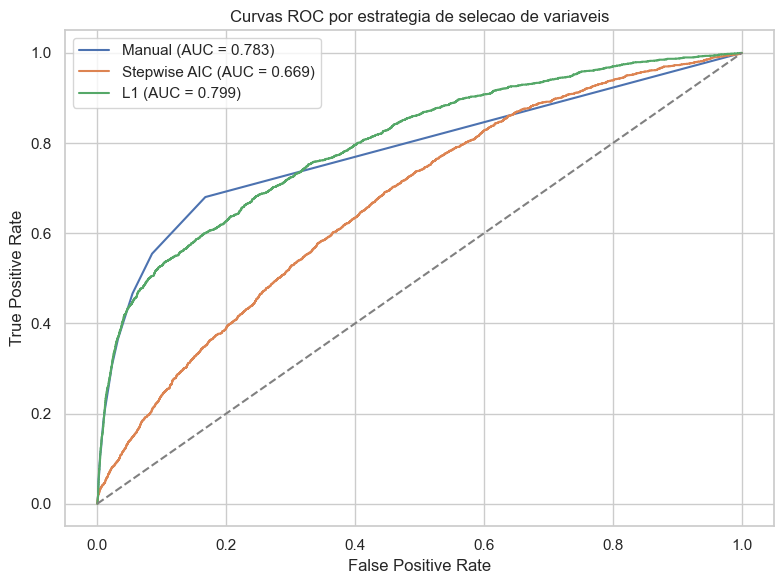

In [37]:
manual_model = sm.GLM(
    y_train1,
    sm.add_constant(X_train1[manual_features], has_constant='add'),
    family=sm.families.Binomial()
).fit()

stepwise_model = sm.GLM(
    y_train1,
    sm.add_constant(X_train1[stepwise_features], has_constant='add'),
    family=sm.families.Binomial()
).fit()

pred_manual_valid = manual_model.predict(
    sm.add_constant(X_valid1[manual_features], has_constant='add')
)
pred_stepwise_valid = stepwise_model.predict(
    sm.add_constant(X_valid1[stepwise_features], has_constant='add')
)
pred_l1_valid = l1_pipe.predict_proba(X_valid1)[:, 1]

fpr_manual, tpr_manual, _ = roc_curve(y_valid1, pred_manual_valid)
fpr_stepwise, tpr_stepwise, _ = roc_curve(y_valid1, pred_stepwise_valid)
fpr_l1, tpr_l1, _ = roc_curve(y_valid1, pred_l1_valid)

plt.figure(figsize=(8, 6))
plt.plot(fpr_manual, tpr_manual, label=f'Manual (AUC = {roc_auc_score(y_valid1, pred_manual_valid):.3f})')
plt.plot(fpr_stepwise, tpr_stepwise, label=f'Stepwise AIC (AUC = {roc_auc_score(y_valid1, pred_stepwise_valid):.3f})')
plt.plot(fpr_l1, tpr_l1, label=f'L1 (AUC = {roc_auc_score(y_valid1, pred_l1_valid):.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC por estrategia de selecao de variaveis')
plt.legend()
plt.tight_layout()
plt.savefig('curvas_roc_selecao_variaveis.pdf', format='pdf', bbox_inches='tight')
plt.show()
